# Modelo para predecir el rango de elección en el Draft

Importo librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

Cargo el dataset

In [2]:
ncaa = pd.read_csv('../datos/procesados/ncaa_final.csv')

## Distribución de la target

Ahora predecimos `rango_pick`: 7 clases (ND + 6 rangos de picks).
El desbalanceo es aún mayor que en el modelo anterior.

In [3]:
print(ncaa['rango_pick'].value_counts())
print()
print(ncaa['rango_pick'].value_counts(normalize=True).round(3))

rango_pick
ND       1500
1-10      108
21-30     108
11-20     106
31-40     104
41-50     102
51-60      93
Name: count, dtype: int64

rango_pick
ND       0.707
1-10     0.051
21-30    0.051
11-20    0.050
31-40    0.049
41-50    0.048
51-60    0.044
Name: proportion, dtype: float64


## Preparo X e y

- `X`: todas las columnas menos `ronda` y `rango_pick`
- `y`: la columna `rango_pick`, codificada con LabelEncoder
- `posicion` se transforma con One-Hot Encoding (variables dummy)

In [4]:
X = ncaa.drop(columns=['ronda', 'rango_pick'])
X = pd.get_dummies(X, columns=['posicion'], drop_first=False)

le_target = LabelEncoder()
y_enc = le_target.fit_transform(ncaa['rango_pick'])

print("Clases:", le_target.classes_)
print("Distribución:", pd.Series(y_enc).value_counts(normalize=True).round(3))

Clases: ['1-10' '11-20' '21-30' '31-40' '41-50' '51-60' 'ND']
Distribución: 6    0.707
0    0.051
2    0.051
1    0.050
3    0.049
4    0.048
5    0.044
Name: proportion, dtype: float64


## División train/test

Uso `stratify` para mantener la proporción de cada rango en train y test.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=11,
    stratify=y_enc
)

print(X_train.shape)
print(X_test.shape)

(1802, 43)
(319, 43)


## Modelo base

XGBoost multiclase con 7 clases. Punto de partida sin ajustes.

In [6]:
modelo = XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=11,
    eval_metric='mlogloss'
)

modelo.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## Evaluación del modelo base

Classification report y matriz de confusión.

In [7]:
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_target.classes_))

              precision    recall  f1-score   support

        1-10       0.07      0.06      0.06        16
       11-20       0.00      0.00      0.00        16
       21-30       0.00      0.00      0.00        16
       31-40       0.11      0.06      0.08        16
       41-50       0.17      0.07      0.10        15
       51-60       0.33      0.14      0.20        14
          ND       0.79      0.97      0.87       226

    accuracy                           0.70       319
   macro avg       0.21      0.19      0.19       319
weighted avg       0.59      0.70      0.64       319



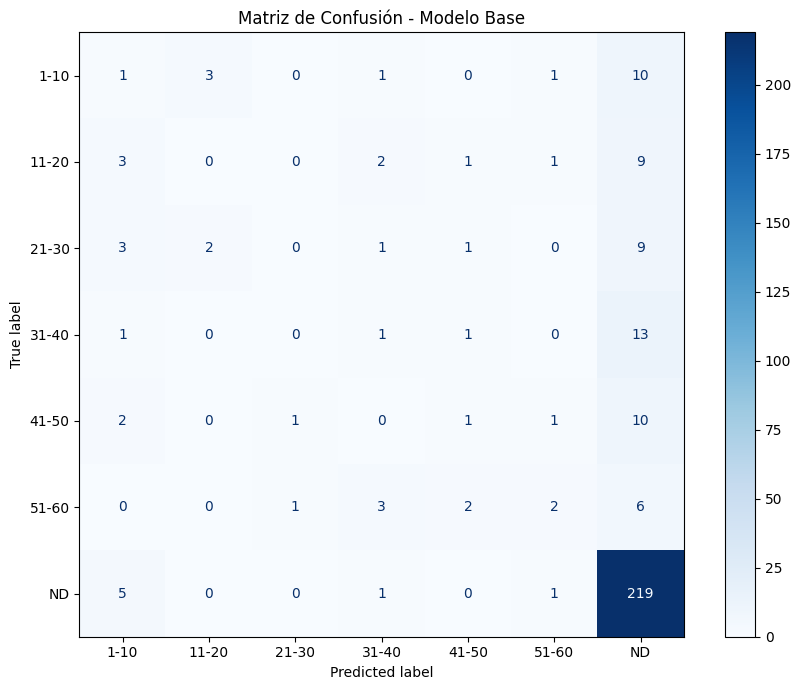

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo Base')
plt.tight_layout()
plt.show()

## Modelo balanceado

El desbalanceo aquí es más extremo (ND = 70%). Aplico pesos por clase
para que el modelo preste más atención a los rangos drafteados.

In [9]:
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

modelo_v2 = XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

modelo_v2.fit(X_train, y_train, sample_weight=pesos)

y_pred_v2 = modelo_v2.predict(X_test)

print(classification_report(y_test, y_pred_v2, target_names=le_target.classes_))

              precision    recall  f1-score   support

        1-10       0.17      0.25      0.20        16
       11-20       0.11      0.12      0.12        16
       21-30       0.00      0.00      0.00        16
       31-40       0.05      0.06      0.06        16
       41-50       0.18      0.13      0.15        15
       51-60       0.31      0.36      0.33        14
          ND       0.86      0.82      0.84       226

    accuracy                           0.63       319
   macro avg       0.24      0.25      0.24       319
weighted avg       0.65      0.63      0.64       319



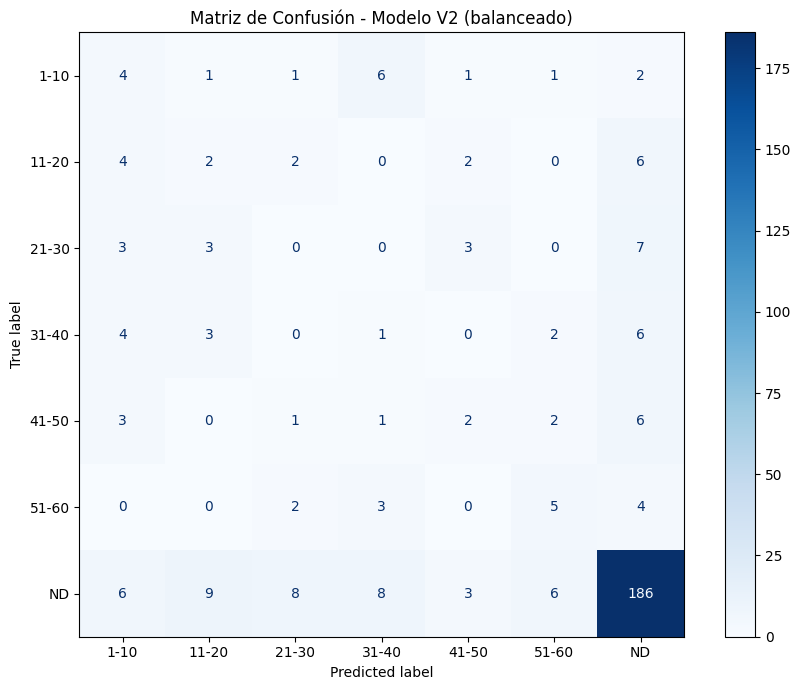

In [10]:
cm2 = confusion_matrix(y_test, y_pred_v2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp2.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo V2 (balanceado)')
plt.tight_layout()
plt.show()

## Guardo el modelo

In [11]:
os.makedirs('../modelos', exist_ok=True)

joblib.dump(modelo_v2, '../modelos/xgb_rango_balanceado.pkl')
joblib.dump(le_target, '../modelos/le_rango.pkl')

print("Modelo guardado")

Modelo guardado


## Predicción con jugador real

Busco el jugador en el raw por nombre y año, cruzo con los datos procesados
por stats únicas, y predigo con probabilidades.

In [12]:
raw = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Cade Cunningham'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
for clase, prob in zip(le_target.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")

Predicción para Cade Cunningham (2021):
  1-10: 84.0%
  11-20: 3.7%
  21-30: 1.6%
  31-40: 1.2%
  41-50: 5.6%
  51-60: 1.1%
  ND: 2.9%

Realidad: Pick #1 → 1-10


In [13]:
raw = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Luka Garza'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
for clase, prob in zip(le_target.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")


Predicción para Luka Garza (2021):
  1-10: 4.0%
  11-20: 2.9%
  21-30: 2.4%
  31-40: 3.3%
  41-50: 3.2%
  51-60: 82.9%
  ND: 1.3%

Realidad: Pick #52 → 51-60


In [14]:
raw = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Santi Aldama'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
for clase, prob in zip(le_target.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")


Predicción para Santi Aldama (2021):
  1-10: 1.4%
  11-20: 3.0%
  21-30: 82.2%
  31-40: 5.3%
  41-50: 1.2%
  51-60: 1.2%
  ND: 5.8%

Realidad: Pick #30 → 21-30
